# 🎯 Project 3: AI Recommendation Logic
**DecodeLab Internship Project**

**Goal:** Create a simple recommendation system based on user preferences.

**Key Skills:** Logic building, pattern matching, recommendation concepts

---

## 📌 What is a Recommendation System?

A recommendation system suggests items that a user might be interested in, based on their preferences or past behavior. Famous examples: **Netflix**, **YouTube**, **Amazon**.

In this project we build two types:
1. **Rule-Based Recommender** — uses `if-else` logic on categories
2. **Similarity-Based Recommender** — uses cosine similarity to find matching products

## Step 1: Import Libraries

In [9]:
import os
os.chdir(r'C:\Users\Azeema\Desktop\Project3_AI_Recommendation')
print(os.getcwd())
print(os.listdir('.'))

C:\Users\Azeema\Desktop\Project3_AI_Recommendation
['.git', 'Product-Sales-Region.xlsx', 'Project3_AI_Recommendation.ipynb', 'README.md', 'venv']


In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported!")

✅ Libraries imported!


## PART A: Rule-Based Product Recommender

Recommends products based on user's stated interest/category.

In [11]:
# ============================================================
# Product catalog with categories and tags
# ============================================================
product_catalog = {
    "tech": [
        {"name": "Laptop",   "price": 850, "rating": 4.5, "tag": "productivity"},
        {"name": "Phone",    "price": 450, "rating": 4.3, "tag": "communication"},
        {"name": "Tablet",   "price": 350, "rating": 4.1, "tag": "portable"},
        {"name": "Monitor",  "price": 300, "rating": 4.4, "tag": "productivity"},
        {"name": "Printer",  "price": 200, "rating": 3.9, "tag": "office"},
    ],
    "furniture": [
        {"name": "Chair",    "price": 150, "rating": 4.2, "tag": "comfort"},
        {"name": "Desk",     "price": 250, "rating": 4.0, "tag": "workspace"},
        {"name": "Bookshelf","price": 180, "rating": 4.1, "tag": "storage"},
        {"name": "Cabinet",  "price": 320, "rating": 3.8, "tag": "storage"},
    ],
    "accessories": [
        {"name": "Headphones","price": 120, "rating": 4.6, "tag": "audio"},
        {"name": "Keyboard",  "price": 75,  "rating": 4.3, "tag": "input"},
        {"name": "Mouse",     "price": 45,  "rating": 4.2, "tag": "input"},
        {"name": "Webcam",    "price": 90,  "rating": 4.0, "tag": "communication"},
    ]
}

print("✅ Product catalog created!")

✅ Product catalog created!


In [12]:
# ============================================================
# RULE-BASED RECOMMENDATION FUNCTION
# ============================================================
def rule_based_recommend(interest, budget=None, top_n=3):
    """
    interest: 'tech', 'furniture', or 'accessories'
    budget  : optional max price filter
    top_n   : number of recommendations
    """
    interest = interest.lower().strip()

    # Match interest to category
    if interest in ["tech", "technology", "electronics", "gadgets", "computer"]:
        category = "tech"
    elif interest in ["furniture", "home", "office furniture", "desk", "chair"]:
        category = "furniture"
    elif interest in ["accessories", "peripherals", "extras", "add-ons"]:
        category = "accessories"
    else:
        return f"❌ Sorry, we don't have recommendations for '{interest}'. Try: tech, furniture, accessories."

    products = product_catalog[category].copy()

    # Apply budget filter
    if budget:
        products = [p for p in products if p['price'] <= budget]
        if not products:
            return f"❌ No products found in '{category}' under ${budget}."

    # Sort by rating (highest first)
    products_sorted = sorted(products, key=lambda x: x['rating'], reverse=True)

    # Return top N
    return products_sorted[:top_n]

print("✅ Rule-based recommender ready!")

✅ Rule-based recommender ready!


In [13]:
# Test the Rule-Based Recommender
def display_recommendations(recs, title="Recommendations"):
    print(f"\n{'='*45}")
    print(f"  🎯 {title}")
    print(f"{'='*45}")
    if isinstance(recs, str):
        print(recs)
        return
    for i, item in enumerate(recs, 1):
        print(f"  {i}. {item['name']:<15} | ${item['price']:<6} | ⭐ {item['rating']} | 🏷️ {item['tag']}")

# Test 1: Tech products, no budget
recs = rule_based_recommend("tech", top_n=3)
display_recommendations(recs, "Top Tech Picks")

# Test 2: Furniture with budget
recs = rule_based_recommend("furniture", budget=200, top_n=3)
display_recommendations(recs, "Furniture Under $200")

# Test 3: Accessories
recs = rule_based_recommend("accessories", top_n=3)
display_recommendations(recs, "Top Accessories")


  🎯 Top Tech Picks
  1. Laptop          | $850    | ⭐ 4.5 | 🏷️ productivity
  2. Monitor         | $300    | ⭐ 4.4 | 🏷️ productivity
  3. Phone           | $450    | ⭐ 4.3 | 🏷️ communication

  🎯 Furniture Under $200
  1. Chair           | $150    | ⭐ 4.2 | 🏷️ comfort
  2. Bookshelf       | $180    | ⭐ 4.1 | 🏷️ storage

  🎯 Top Accessories
  1. Headphones      | $120    | ⭐ 4.6 | 🏷️ audio
  2. Keyboard        | $75     | ⭐ 4.3 | 🏷️ input
  3. Mouse           | $45     | ⭐ 4.2 | 🏷️ input


## PART B: Similarity-Based Recommender

Uses **Cosine Similarity** to recommend products similar to what a user liked before (from the real dataset).

In [14]:
import os

# Check what's in the current folder
print("Current folder:", os.getcwd())
print("Files here:", os.listdir('.'))

# Load with full path
df = pd.read_excel('Product-Sales-Region.xlsx')
print("✅ Dataset loaded!")
print(df[['Product', 'Quantity', 'UnitPrice', 'TotalPrice']].head())

Current folder: C:\Users\Azeema\Desktop\Project3_AI_Recommendation
Files here: ['.git', 'Product-Sales-Region.xlsx', 'Project3_AI_Recommendation.ipynb', 'README.md', 'venv']
✅ Dataset loaded!
  Product  Quantity  UnitPrice  TotalPrice
0  Laptop        14     163.60    2290.400
1   Phone         1     544.01     544.010
2    Desk        14     346.18    4361.868
3   Chair        18     384.82    5887.746
4    Desk        18     237.76    4279.680


In [15]:
# Build a product feature matrix for similarity
# Group by Product: average Quantity, UnitPrice, TotalPrice, and count of orders

product_features = df.groupby('Product').agg(
    avg_quantity = ('Quantity', 'mean'),
    avg_price    = ('UnitPrice', 'mean'),
    avg_total    = ('TotalPrice', 'mean'),
    order_count  = ('OrderID', 'count')
).reset_index()

print("📊 Product Feature Matrix:")
print(product_features)

📊 Product Feature Matrix:
   Product  avg_quantity   avg_price    avg_total  order_count
0    Chair     10.153110  319.703541  2978.897024          209
1     Desk      9.787440  295.180628  2682.447655          207
2   Laptop     10.654867  303.733274  3028.394874          226
3  Monitor     10.268868  317.296651  3073.723550          212
4    Phone     10.102564  271.192256  2549.553082          195
5  Printer     11.071090  301.933318  3243.542254          211
6   Tablet     10.737500  282.579000  2852.247440          240


In [16]:
# Compute cosine similarity between products
feature_matrix = product_features[['avg_quantity', 'avg_price', 'avg_total', 'order_count']].values

# Normalize
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
feature_matrix_scaled = scaler.fit_transform(feature_matrix)

# Cosine Similarity
similarity_matrix = cosine_similarity(feature_matrix_scaled)
product_names = product_features['Product'].tolist()

sim_df = pd.DataFrame(similarity_matrix, index=product_names, columns=product_names)

print("\n🔗 Similarity Matrix:")
print(sim_df.round(2))


🔗 Similarity Matrix:
         Chair  Desk  Laptop  Monitor  Phone  Printer  Tablet
Chair     1.00  0.94    0.88     0.99   0.23     0.83    0.61
Desk      0.94  1.00    0.80     0.91   0.00     0.64    0.59
Laptop    0.88  0.80    1.00     0.93   0.50     0.94    0.90
Monitor   0.99  0.91    0.93     1.00   0.28     0.89    0.68
Phone     0.23  0.00    0.50     0.28   1.00     0.63    0.55
Printer   0.83  0.64    0.94     0.89   0.63     1.00    0.79
Tablet    0.61  0.59    0.90     0.68   0.55     0.79    1.00


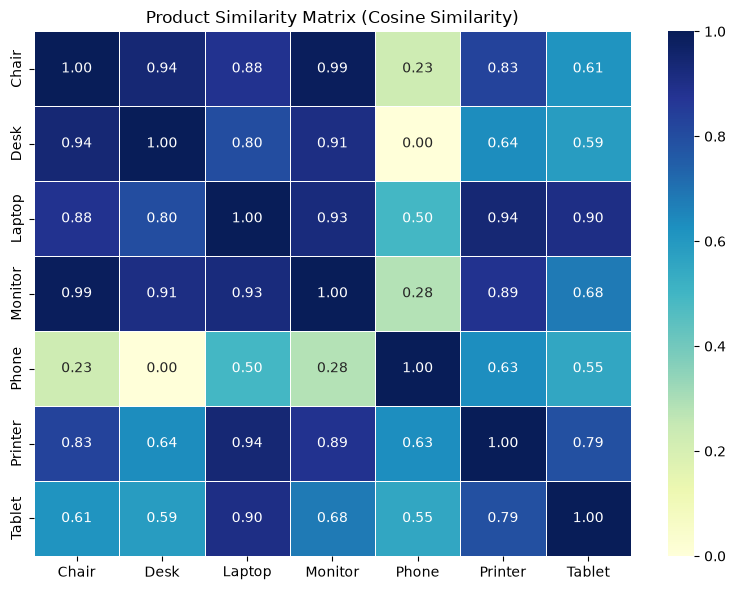

In [17]:
# Visualize the similarity matrix
plt.figure(figsize=(8, 6))
sns.heatmap(sim_df, annot=True, fmt='.2f', cmap='YlGnBu', linewidths=0.5)
plt.title('Product Similarity Matrix (Cosine Similarity)')
plt.tight_layout()
plt.show()

In [18]:
# ============================================================
# SIMILARITY-BASED RECOMMENDATION FUNCTION
# ============================================================
def similarity_recommend(liked_product, top_n=3):
    """
    Given a product the user likes, recommend similar ones.
    """
    liked_product = liked_product.strip().title()

    if liked_product not in product_names:
        available = ", ".join(product_names)
        return f"❌ Product '{liked_product}' not found. Available: {available}"

    # Get similarity scores for this product
    scores = sim_df[liked_product].drop(liked_product).sort_values(ascending=False)

    # Get top N recommendations
    top_recs = scores.head(top_n)

    print(f"\n{'='*45}")
    print(f"  📦 Because you liked: {liked_product}")
    print(f"  You might also like:")
    print(f"{'='*45}")
    for rank, (product, score) in enumerate(top_recs.items(), 1):
        print(f"  {rank}. {product:<12} | Similarity Score: {score:.2f}")


# Test the recommender
similarity_recommend("Laptop", top_n=3)
similarity_recommend("Phone", top_n=3)
similarity_recommend("Desk", top_n=3)


  📦 Because you liked: Laptop
  You might also like:
  1. Printer      | Similarity Score: 0.94
  2. Monitor      | Similarity Score: 0.93
  3. Tablet       | Similarity Score: 0.90

  📦 Because you liked: Phone
  You might also like:
  1. Printer      | Similarity Score: 0.63
  2. Tablet       | Similarity Score: 0.55
  3. Laptop       | Similarity Score: 0.50

  📦 Because you liked: Desk
  You might also like:
  1. Chair        | Similarity Score: 0.94
  2. Monitor      | Similarity Score: 0.91
  3. Laptop       | Similarity Score: 0.80


## PART C: Interactive Recommendation System

In [ ]:
# ============================================================
#  INTERACTIVE RECOMMENDATION SYSTEM
# ============================================================

print("="*50)
print("  🤖 AI PRODUCT RECOMMENDER")
print("="*50)
print("  Mode 1: Category-based (rule-based)")
print("  Mode 2: Product similarity-based")
print("="*50)

mode = input("\nChoose mode (1 or 2): ").strip()

if mode == "1":
    interest = input("Enter your interest (tech / furniture / accessories): ")
    budget_input = input("Enter max budget in $ (or press Enter to skip): ")
    budget = int(budget_input) if budget_input.strip() else None

    recs = rule_based_recommend(interest, budget=budget, top_n=3)
    display_recommendations(recs, f"Top Picks for '{interest}'")

elif mode == "2":
    print(f"\n📦 Available products: {', '.join(product_names)}")
    liked = input("Which product did you like? ")
    similarity_recommend(liked, top_n=3)

else:
    print("❌ Invalid mode. Please run again and choose 1 or 2.")

  🤖 AI PRODUCT RECOMMENDER
  Mode 1: Category-based (rule-based)
  Mode 2: Product similarity-based


## ✅ Summary

| Part | Method | Description |
|------|--------|-------------|
| A | Rule-Based | Uses if-else logic + budget filter |
| B | Similarity-Based | Uses cosine similarity on product features |
| C | Interactive | Takes user input and recommends in real time |

---
🎓 **DecodeLab Internship — Project 3 Complete!**